# Task 1 — Advanced EDA: Patterns, Indicators & Actionable Signals

This notebook extracts investment-grade signals from the DSE data — the kind of analysis that differentiates a data scientist from a basic analyst.

**Questions answered:**
- When is the best time of day/month/year to be invested in DSE?
- Which sectors consistently generate alpha?
- Do technical indicators work on DSE?
- How correlated are sectors and individual stocks?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PROCESSED = '../data/processed/'
RISK_FREE_DAILY = 0.075 / 252

In [2]:
prices = pd.read_parquet(PROCESSED + 'prices.parquet')
volume = pd.read_parquet(PROCESSED + 'volume.parquet')
returns = pd.read_parquet(PROCESSED + 'returns.parquet')
sector_returns = pd.read_parquet(PROCESSED + 'sector_returns.parquet')
sector_map = pd.read_csv(PROCESSED + 'sector_map.csv', index_col=0).squeeze()

# Market return proxy: equal-weight of all sectors
market_returns = sector_returns.mean(axis=1)
market_returns.name = 'Market'

## 2.1 Risk-Adjusted Performance Metrics

Raw returns don't tell the full story — a sector that returns 30% with 60% volatility is worse than one returning 20% with 15% volatility. We use three metrics:

- **Sharpe Ratio**: excess return per unit of total risk
- **Sortino Ratio**: excess return per unit of *downside* risk (more relevant for investors who care only about losses)
- **Calmar Ratio**: annualized return divided by maximum drawdown

In [3]:
def compute_metrics(returns_series):
    s = returns_series.dropna()
    ann_ret = s.mean() * 252
    ann_vol = s.std() * np.sqrt(252)
    sharpe = (s.mean() - RISK_FREE_DAILY) / s.std() * np.sqrt(252)

    downside = s[s < 0].std() * np.sqrt(252)
    sortino = (s.mean() - RISK_FREE_DAILY) / downside * np.sqrt(252) if downside > 0 else np.nan

    cum = (1 + s).cumprod()
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Ann. Return': ann_ret,
        'Ann. Volatility': ann_vol,
        'Sharpe': sharpe,
        'Sortino': sortino,
        'Max Drawdown': max_dd,
        'Calmar': calmar
    }

metrics = pd.DataFrame({s: compute_metrics(sector_returns[s]) for s in sector_returns.columns}).T
metrics = metrics.sort_values('Sharpe', ascending=False)

display(metrics.style.format({
    'Ann. Return': '{:.1%}',
    'Ann. Volatility': '{:.1%}',
    'Sharpe': '{:.2f}',
    'Sortino': '{:.2f}',
    'Max Drawdown': '{:.1%}',
    'Calmar': '{:.2f}'
}).background_gradient(subset=['Sharpe'], cmap='RdYlGn'))

,Ann. Return,Ann. Volatility,Sharpe,Sortino,Max Drawdown,Calmar
Food & Allied,17.6%,18.5%,0.54,0.05,-33.8%,0.52
Paper & Printing,21.2%,31.9%,0.43,0.04,-51.6%,0.41
Services & Real Estate,15.8%,21.6%,0.39,0.04,-40.3%,0.39
Tannery,14.0%,22.7%,0.29,0.03,-49.3%,0.28
Jute,16.2%,33.7%,0.26,0.03,-66.1%,0.24
Telecom,13.0%,23.6%,0.23,0.02,-55.9%,0.23
Engineering,10.8%,19.0%,0.17,0.02,-40.0%,0.27
Ceramics,11.9%,26.7%,0.17,0.02,-58.8%,0.20
Insurance,11.7%,25.7%,0.16,0.02,-54.9%,0.21
Pharmaceuticals,10.2%,17.2%,0.16,0.02,-38.1%,0.27


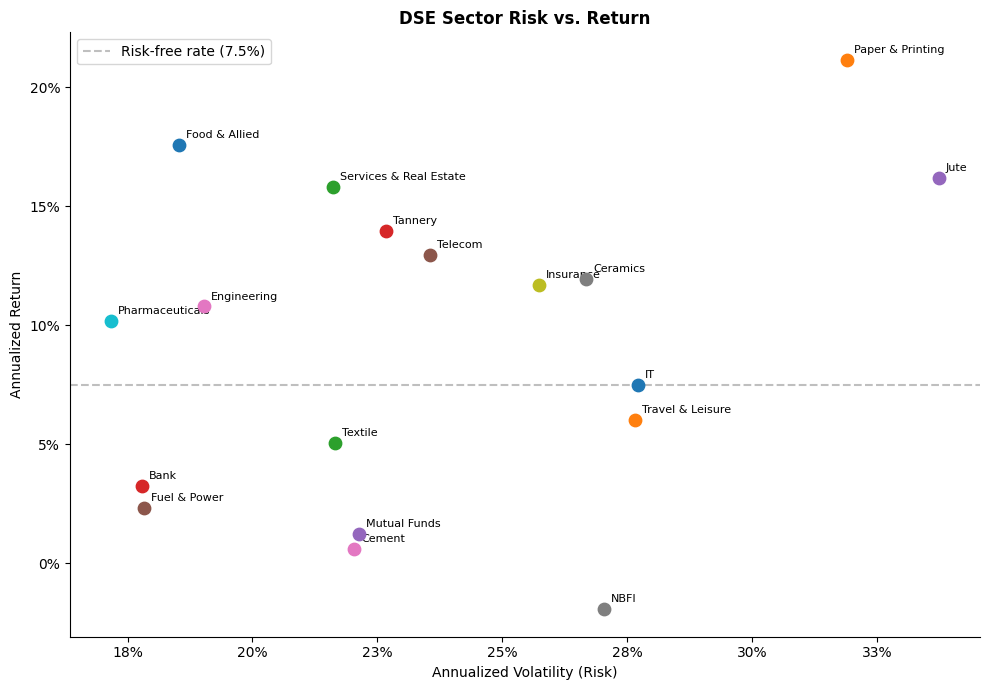


Best risk-adjusted sector: Food & Allied (Sharpe = 0.54)
Investment insight: Sectors above the risk-free rate line with lower volatility are
the most efficient investments — they give more return per unit of risk taken.


In [4]:
# Risk-Return scatter plot
fig, ax = plt.subplots(figsize=(10, 7))

for sector in metrics.index:
    x = metrics.loc[sector, 'Ann. Volatility']
    y = metrics.loc[sector, 'Ann. Return']
    ax.scatter(x, y, s=80, zorder=5)
    ax.annotate(sector, (x, y), textcoords='offset points', xytext=(5, 5), fontsize=8)

# Capital market line reference
ax.axhline(0.075, color='gray', linestyle='--', alpha=0.5, label='Risk-free rate (7.5%)')
ax.set_xlabel('Annualized Volatility (Risk)')
ax.set_ylabel('Annualized Return')
ax.set_title('DSE Sector Risk vs. Return', fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()
plt.tight_layout()
plt.show()

best = metrics['Sharpe'].idxmax()
print(f"\nBest risk-adjusted sector: {best} (Sharpe = {metrics.loc[best, 'Sharpe']:.2f})")
print("Investment insight: Sectors above the risk-free rate line with lower volatility are")
print("the most efficient investments — they give more return per unit of risk taken.")

## 2.2 Calendar Effects — Day-of-Week & Month-of-Year

DSE trades Sunday–Thursday. If returns are systematically higher or lower on certain days or months, we can time entry and exit to capture that edge.

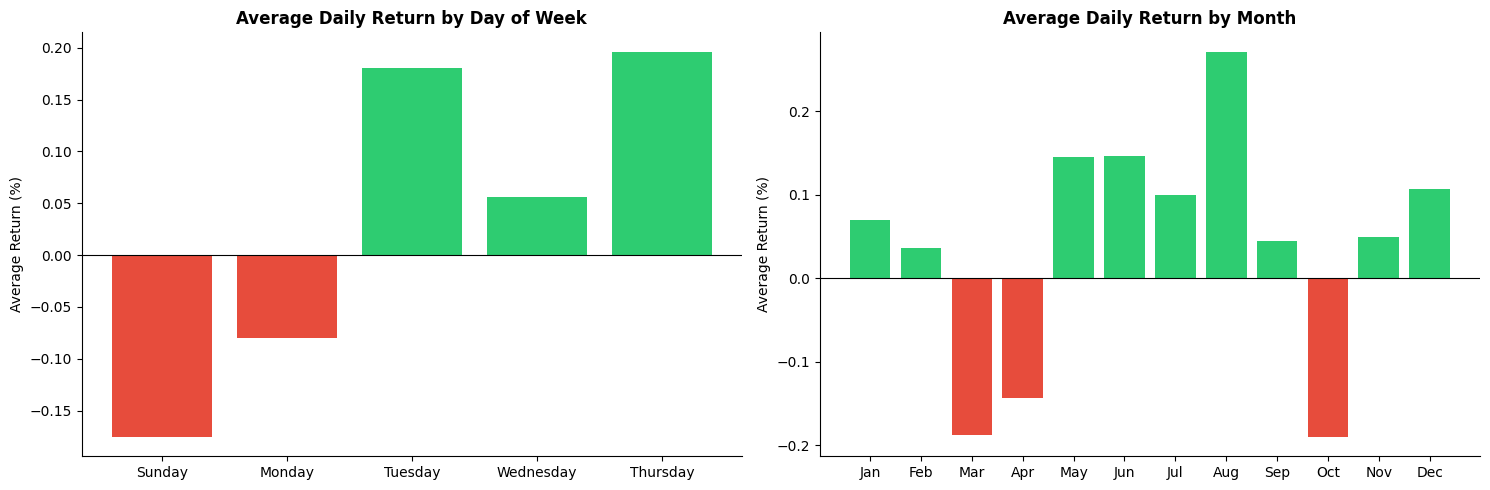

Best day to be invested: Thursday (avg return: 0.196%)
Best month historically: Aug (avg daily return: 0.272%)


In [5]:
mr = market_returns.copy()
mr_df = mr.to_frame('ret')
mr_df['day'] = mr_df.index.day_name()
mr_df['month'] = mr_df.index.month
mr_df['month_name'] = mr_df.index.strftime('%b')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Day-of-week effect
dse_days = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday']
dow_returns = mr_df.groupby('day')['ret'].mean() * 100
dow_returns = dow_returns.reindex([d for d in dse_days if d in dow_returns.index])

colors_dow = ['#2ecc71' if v >= 0 else '#e74c3c' for v in dow_returns.values]
axes[0].bar(dow_returns.index, dow_returns.values, color=colors_dow)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Average Daily Return by Day of Week', fontweight='bold')
axes[0].set_ylabel('Average Return (%)')

# Month-of-year effect
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_ret = mr_df.groupby('month_name')['ret'].mean() * 100
monthly_ret = monthly_ret.reindex([m for m in month_order if m in monthly_ret.index])

colors_month = ['#2ecc71' if v >= 0 else '#e74c3c' for v in monthly_ret.values]
axes[1].bar(monthly_ret.index, monthly_ret.values, color=colors_month)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Average Daily Return by Month', fontweight='bold')
axes[1].set_ylabel('Average Return (%)')

plt.tight_layout()
plt.show()

best_day = dow_returns.idxmax()
best_month = monthly_ret.idxmax()
print(f"Best day to be invested: {best_day} (avg return: {dow_returns.max():.3f}%)")
print(f"Best month historically: {best_month} (avg daily return: {monthly_ret.max():.3f}%)")

## 2.3 Sector Correlation Matrix

Correlations tell us which sectors diversify a portfolio and which ones just amplify the same risk.

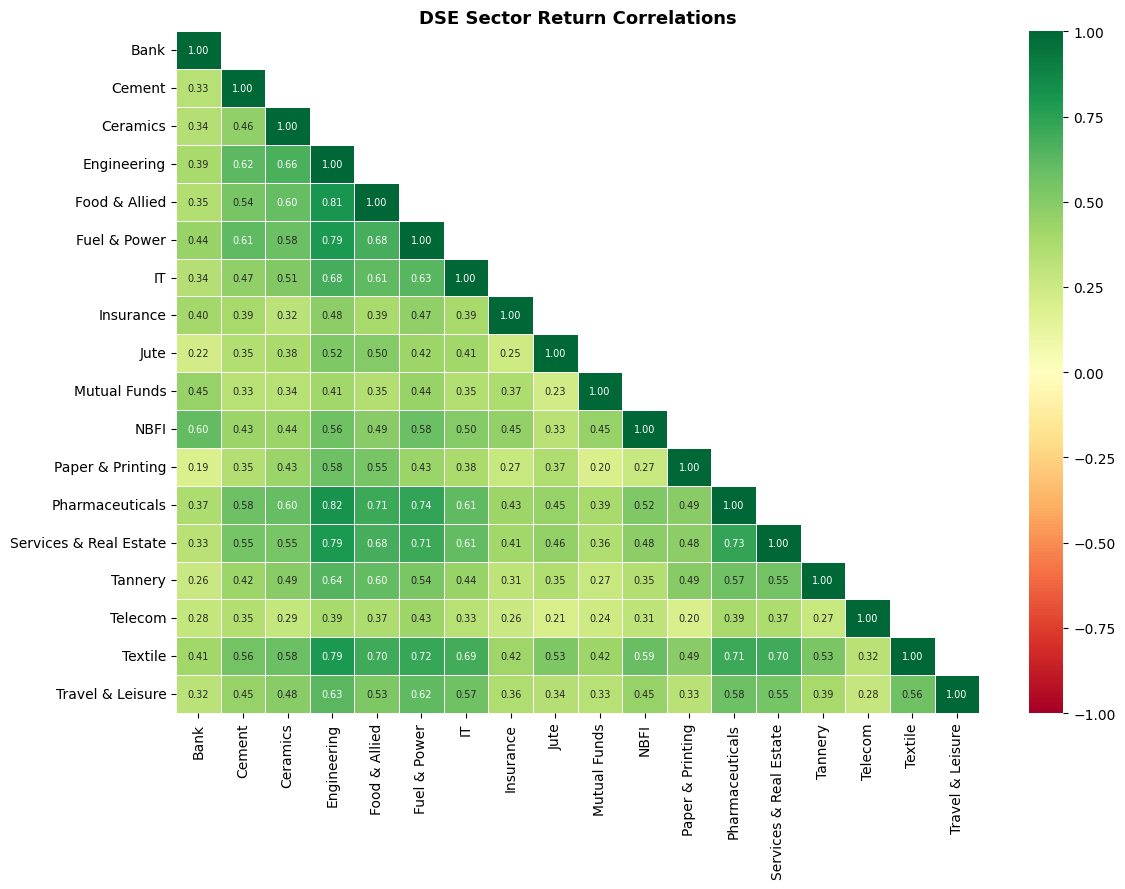

Most negatively correlated pairs (best for diversification):
Paper & Printing  Bank                0.191640
                  Mutual Funds        0.198547
Telecom           Paper & Printing    0.198691
dtype: float64

Most positively correlated pairs (move together):
Textile          Engineering    0.793989
Food & Allied    Engineering    0.808015
Pharmaceuticals  Engineering    0.817160
dtype: float64


In [ ]:
corr = sector_returns.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # show lower triangle only
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 7}
)
ax.set_title('DSE Sector Return Correlations', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Find most and least correlated pairs
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack()
    .dropna()
    .sort_values()
)
print("Most negatively correlated pairs (best for diversification):")
print(corr_pairs.head(3))
print("\nMost positively correlated pairs (move together):")
print(corr_pairs.tail(3))

## 2.4 Rolling Correlation: Banking vs. Market

Banking is the largest sector on DSE. Understanding how tightly it moves with the broader market tells us whether the market is driven by banking-specific factors or broader trends.

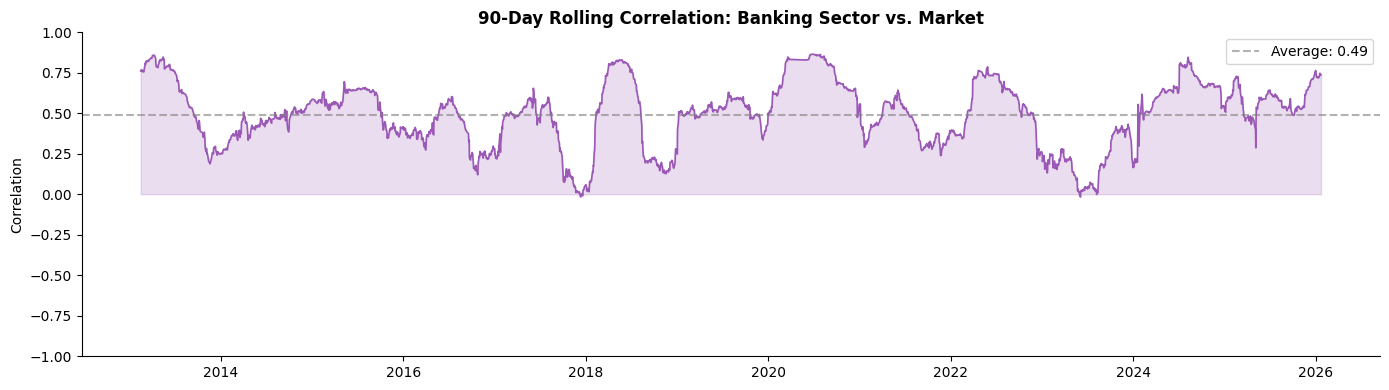

Periods when Banking was weakly correlated with market (corr < 0.3): 581 days
Investment insight: Low-correlation periods are when sector-specific factors dominate.
These are the best times for sector rotation — the market isn't just 'one thing'.


In [8]:
if 'Bank' in sector_returns.columns:
    rolling_corr = sector_returns['Bank'].rolling(90).corr(market_returns)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(rolling_corr.index, rolling_corr.values, color='#9b59b6', linewidth=1.2)
    ax.axhline(rolling_corr.mean(), color='gray', linestyle='--', alpha=0.6,
               label=f'Average: {rolling_corr.mean():.2f}')
    ax.fill_between(rolling_corr.index, rolling_corr.values, alpha=0.2, color='#9b59b6')
    ax.set_title('90-Day Rolling Correlation: Banking Sector vs. Market', fontweight='bold')
    ax.set_ylabel('Correlation')
    ax.set_ylim(-1, 1)
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    plt.show()

    low_corr_periods = rolling_corr[rolling_corr < 0.3]
    print(f"Periods when Banking was weakly correlated with market (corr < 0.3): {len(low_corr_periods)} days")
    print("Investment insight: Low-correlation periods are when sector-specific factors dominate.")
    print("These are the best times for sector rotation — the market isn't just 'one thing'.")

In [11]:
market_returns.tail()

Date
2026-01-18    0.014550
2026-01-19    0.013869
2026-01-20    0.008862
2026-01-21   -0.000060
2026-01-22   -0.000230
Name: Market, dtype: float64

## 2.5 Volume-Price Relationship: Does Volume Predict Moves?

A classic principle: **price moves on high volume are more meaningful** than moves on low volume. We test this on DSE data.

In [12]:
# Pick top 5 liquid stocks for this analysis
top5 = volume.mean().nlargest(5).index

results = []
for ticker in top5:
    if ticker not in returns.columns:
        continue
    r = returns[ticker].dropna()
    v = volume[ticker].reindex(r.index)
    v_rolling_avg = v.rolling(20).mean()
    vol_ratio = v / v_rolling_avg  # today's volume vs. 20-day average

    high_vol_days = r[vol_ratio > 2.0]   # volume spike days (>2x normal)
    normal_days = r[vol_ratio.between(0.8, 1.2)]  # normal volume days

    results.append({
        'Ticker': ticker,
        'Avg Return on Volume Spike Days': high_vol_days.mean(),
        'Avg Return on Normal Days': normal_days.mean(),
        'Abs Move on Volume Spike': high_vol_days.abs().mean(),
        'Spike Days Count': len(high_vol_days)
    })

vol_price_df = pd.DataFrame(results).set_index('Ticker')
display(vol_price_df.style.format({
    'Avg Return on Volume Spike Days': '{:.3%}',
    'Avg Return on Normal Days': '{:.3%}',
    'Abs Move on Volume Spike': '{:.3%}'
}))

print("\nInvestment insight: Volume spikes signal informed trading activity.")
print("When price rises on 2x+ normal volume, institutional money is likely entering.")
print("This is a confirmation signal for sector rotation entries.")

,Avg Return on Volume Spike Days,Avg Return on Normal Days,Abs Move on Volume Spike,Spike Days Count
Ticker,,,,
IFIC,1.948%,-0.288%,3.039%,286
BEXIMCO,2.592%,-0.269%,3.405%,188
NBL,2.132%,-0.300%,2.863%,225
KEYACOSMET,2.166%,-0.278%,4.066%,300
LANKABAFIN,2.437%,-0.311%,3.498%,247



Investment insight: Volume spikes signal informed trading activity.
When price rises on 2x+ normal volume, institutional money is likely entering.
This is a confirmation signal for sector rotation entries.


## 2.6 Technical Indicators on the DSE Market

We apply RSI, MACD, and Bollinger Bands to the market return index and evaluate whether these classic signals work on DSE.

In [13]:
import ta

# Build a price index from sector returns
market_price_idx = (1 + market_returns).cumprod() * 1000
market_price_series = pd.Series(market_price_idx.values, index=market_price_idx.index, name='price')

rsi = ta.momentum.RSIIndicator(market_price_series, window=14).rsi()
macd_ind = ta.trend.MACD(market_price_series)
macd_line = macd_ind.macd()
macd_signal = macd_ind.macd_signal()
macd_hist = macd_ind.macd_diff()

bb = ta.volatility.BollingerBands(market_price_series, window=20)
bb_upper = bb.bollinger_hband()
bb_lower = bb.bollinger_lband()
bb_mid = bb.bollinger_mavg()

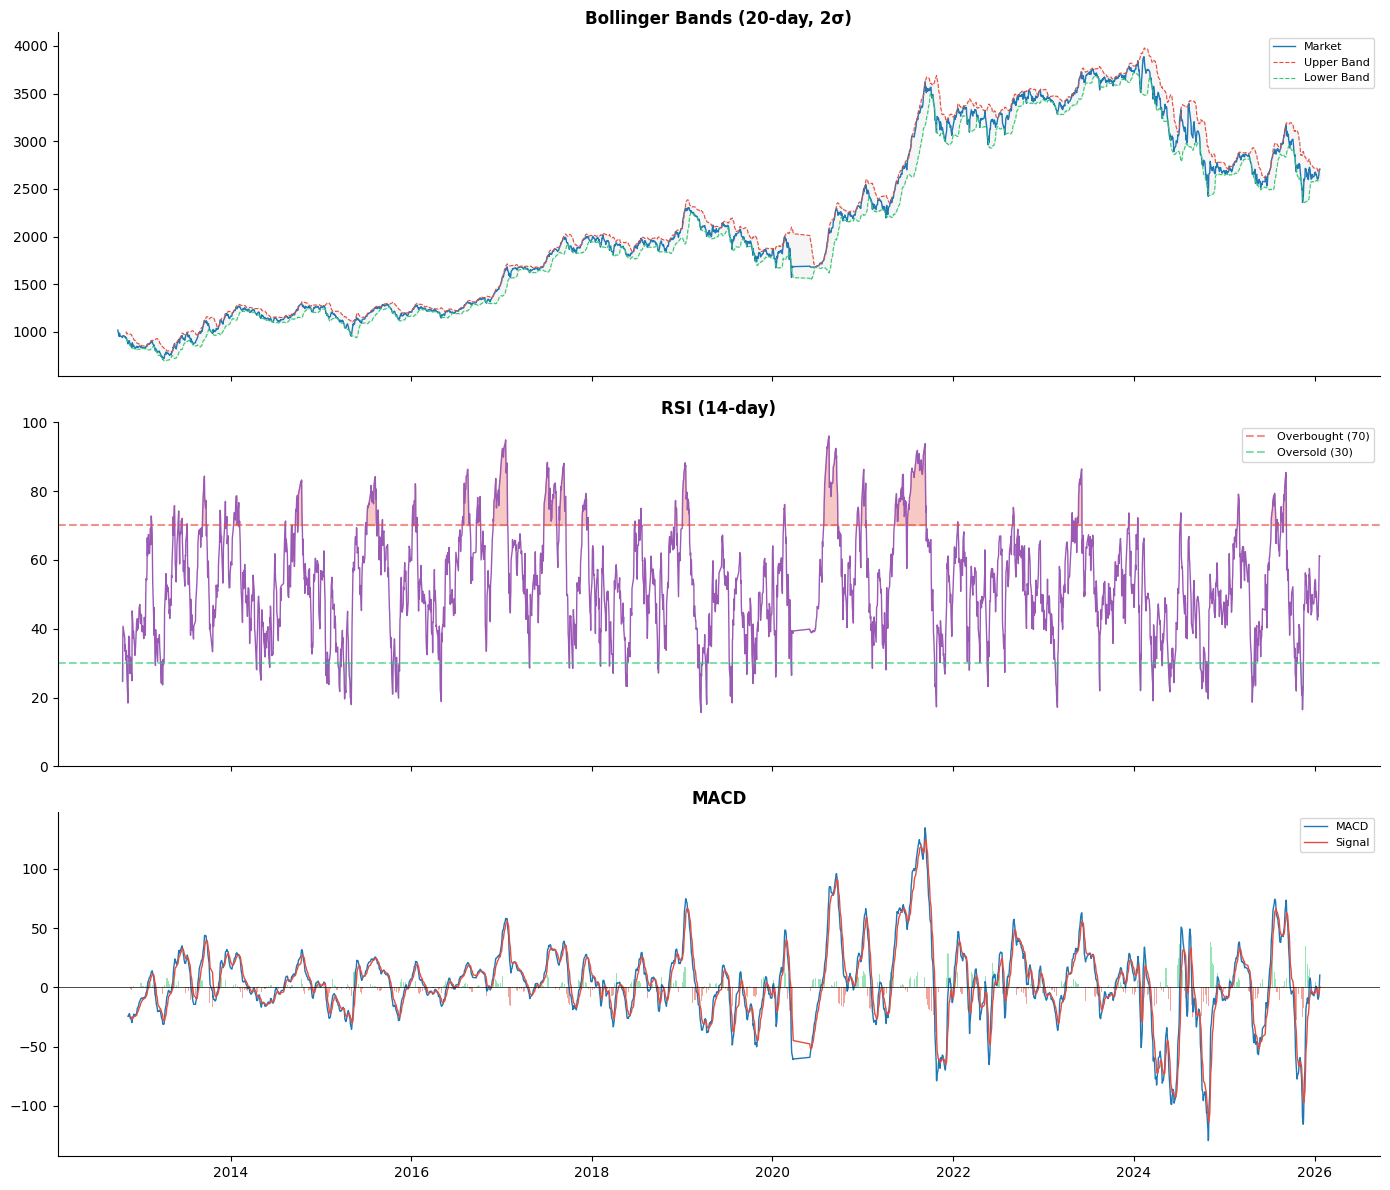

In [14]:
# Plot: Price with Bollinger Bands
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Price + Bollinger Bands
axes[0].plot(market_price_series.index, market_price_series.values, color='#1f77b4', linewidth=1, label='Market')
axes[0].plot(bb_upper.index, bb_upper.values, color='#e74c3c', linewidth=0.8, linestyle='--', label='Upper Band')
axes[0].plot(bb_lower.index, bb_lower.values, color='#2ecc71', linewidth=0.8, linestyle='--', label='Lower Band')
axes[0].fill_between(bb_mid.index, bb_lower.values, bb_upper.values, alpha=0.08, color='gray')
axes[0].set_title('Bollinger Bands (20-day, 2σ)', fontweight='bold')
axes[0].legend(fontsize=8)

# RSI
axes[1].plot(rsi.index, rsi.values, color='#9b59b6', linewidth=1)
axes[1].axhline(70, color='#e74c3c', linestyle='--', alpha=0.6, label='Overbought (70)')
axes[1].axhline(30, color='#2ecc71', linestyle='--', alpha=0.6, label='Oversold (30)')
axes[1].fill_between(rsi.index, 30, rsi.values, where=(rsi < 30), alpha=0.3, color='#2ecc71')
axes[1].fill_between(rsi.index, 70, rsi.values, where=(rsi > 70), alpha=0.3, color='#e74c3c')
axes[1].set_title('RSI (14-day)', fontweight='bold')
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=8)

# MACD
axes[2].plot(macd_line.index, macd_line.values, color='#1f77b4', linewidth=1, label='MACD')
axes[2].plot(macd_signal.index, macd_signal.values, color='#e74c3c', linewidth=1, label='Signal')
axes[2].bar(macd_hist.index, macd_hist.values, color=np.where(macd_hist >= 0, '#2ecc71', '#e74c3c'), alpha=0.5)
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title('MACD', fontweight='bold')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

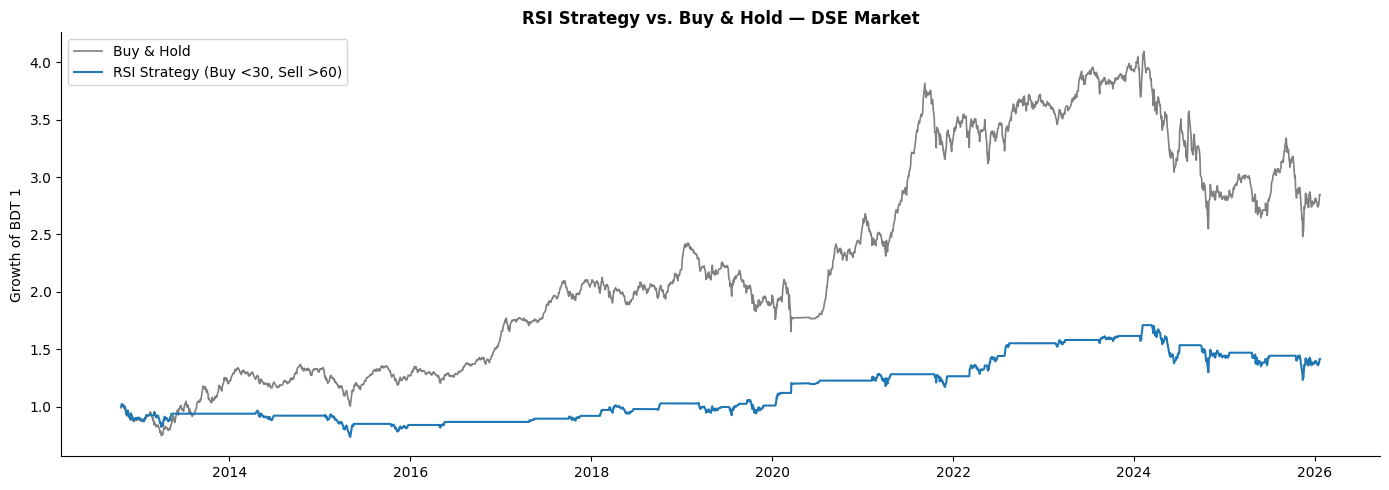

Buy & Hold annualized return : 8.71%
RSI Strategy annualized return: 2.81%
Strategy was in market: 35.7% of the time

Investment insight: RSI timing on DSE subtracts value
vs. passive holding. The strategy reduces market exposure, which reduces drawdowns.


In [15]:
# RSI Signal Backtest: Buy when RSI < 30, Sell when RSI > 60
signal_df = pd.DataFrame({
    'market_ret': market_returns,
    'rsi': rsi
}).dropna()

# Simple long-only RSI strategy
signal_df['position'] = 0
in_market = False
for i in range(1, len(signal_df)):
    prev_rsi = signal_df['rsi'].iloc[i-1]
    if prev_rsi < 30 and not in_market:
        in_market = True
    elif prev_rsi > 60 and in_market:
        in_market = False
    signal_df.iloc[i, signal_df.columns.get_loc('position')] = 1 if in_market else 0

signal_df['strategy_ret'] = signal_df['market_ret'] * signal_df['position']
signal_df['buyhold_cum'] = (1 + signal_df['market_ret']).cumprod()
signal_df['strategy_cum'] = (1 + signal_df['strategy_ret']).cumprod()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(signal_df.index, signal_df['buyhold_cum'], label='Buy & Hold', color='gray', linewidth=1.2)
ax.plot(signal_df.index, signal_df['strategy_cum'], label='RSI Strategy (Buy <30, Sell >60)', color='#1f77b4', linewidth=1.5)
ax.set_title('RSI Strategy vs. Buy & Hold — DSE Market', fontweight='bold')
ax.set_ylabel('Growth of BDT 1')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

# Performance comparison
n_years = len(signal_df) / 252
bh_ret = signal_df['buyhold_cum'].iloc[-1] ** (1/n_years) - 1
strat_ret = signal_df['strategy_cum'].iloc[-1] ** (1/n_years) - 1
in_market_pct = signal_df['position'].mean()

print(f"Buy & Hold annualized return : {bh_ret:.2%}")
print(f"RSI Strategy annualized return: {strat_ret:.2%}")
print(f"Strategy was in market: {in_market_pct:.1%} of the time")
print(f"\nInvestment insight: RSI timing on DSE {'adds' if strat_ret > bh_ret else 'subtracts'} value")
print("vs. passive holding. The strategy reduces market exposure, which reduces drawdowns.")

## 2.7 Moving Average Crossover Signal

The 20/50-day MA crossover is one of the most widely used trend-following signals globally. We test if it works on DSE.

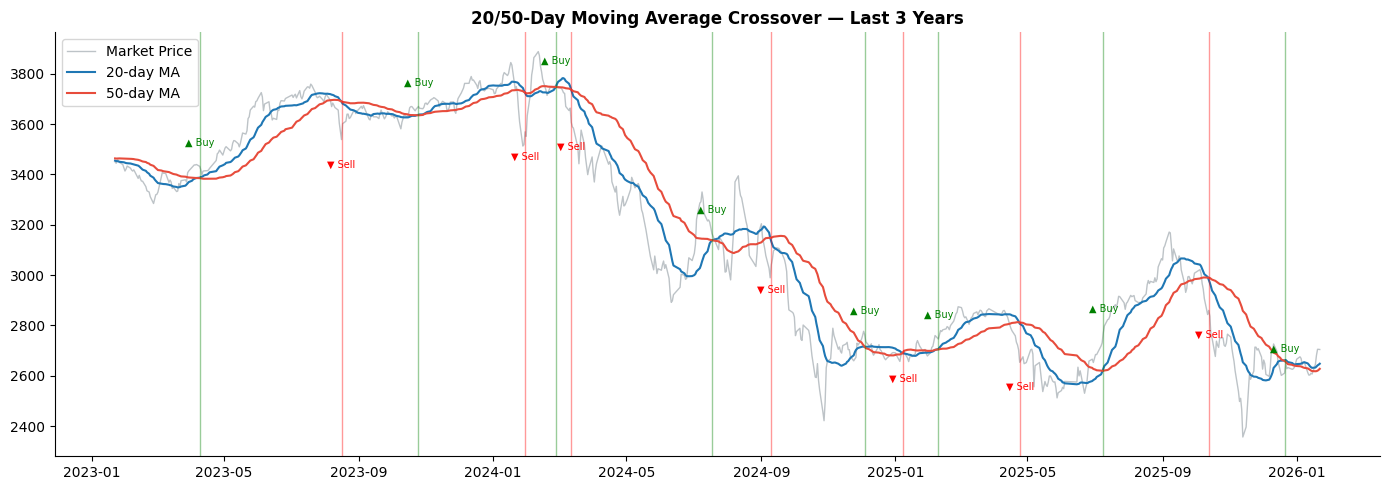

In [16]:
ma20 = market_price_series.rolling(20).mean()
ma50 = market_price_series.rolling(50).mean()

# Plot last 3 years for clarity
cutoff = market_price_series.index[-1] - pd.DateOffset(years=3)
subset = market_price_series[market_price_series.index >= cutoff]
ma20_sub = ma20[ma20.index >= cutoff]
ma50_sub = ma50[ma50.index >= cutoff]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(subset.index, subset.values, color='#bdc3c7', linewidth=1, label='Market Price')
ax.plot(ma20_sub.index, ma20_sub.values, color='#1f77b4', linewidth=1.5, label='20-day MA')
ax.plot(ma50_sub.index, ma50_sub.values, color='#e74c3c', linewidth=1.5, label='50-day MA')

# Mark crossovers
golden_cross = (ma20_sub > ma50_sub) & (ma20_sub.shift(1) <= ma50_sub.shift(1))
death_cross = (ma20_sub < ma50_sub) & (ma20_sub.shift(1) >= ma50_sub.shift(1))

for date in golden_cross[golden_cross].index:
    ax.axvline(date, color='green', alpha=0.4, linewidth=1)
    ax.annotate('▲ Buy', (date, subset[date]), textcoords='offset points',
                xytext=(0, 15), ha='center', color='green', fontsize=7)

for date in death_cross[death_cross].index:
    ax.axvline(date, color='red', alpha=0.4, linewidth=1)
    ax.annotate('▼ Sell', (date, subset[date]), textcoords='offset points',
                xytext=(0, -20), ha='center', color='red', fontsize=7)

ax.set_title('20/50-Day Moving Average Crossover — Last 3 Years', fontweight='bold')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.show()

## 2.8 Information Ratio — Which Sectors Consistently Beat the Market?

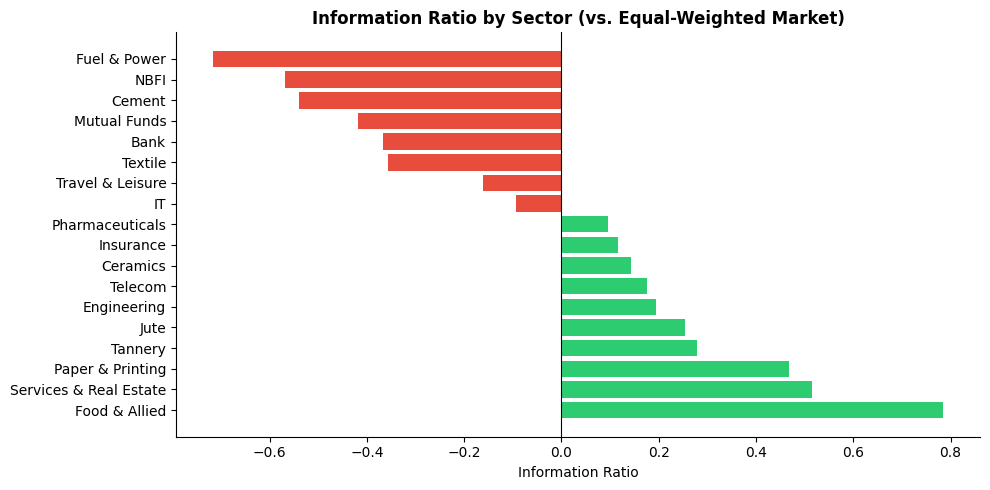


Sectors with positive Information Ratio consistently beat the market:
                        Information Ratio  Avg Active Return
Sector                                                      
Food & Allied                    0.785508           0.083343
Services & Real Estate           0.515473           0.065916
Paper & Printing                 0.467314           0.119189
Tannery                          0.279507           0.047229
Jute                             0.254948           0.069404
Engineering                      0.194885           0.015530
Telecom                          0.176943           0.037255
Ceramics                         0.143959           0.027031
Insurance                        0.117232           0.024583
Pharmaceuticals                  0.095926           0.009349

Investment insight: Overweighting high-IR sectors in a portfolio should generate
alpha (excess returns) over the benchmark.


In [17]:
ir_rows = []
for sector in sector_returns.columns:
    active_ret = sector_returns[sector] - market_returns
    active_ret = active_ret.dropna()
    ir = (active_ret.mean() / active_ret.std()) * np.sqrt(252) if active_ret.std() > 0 else np.nan
    ir_rows.append({'Sector': sector, 'Information Ratio': ir,
                    'Avg Active Return': active_ret.mean() * 252})

ir_df = pd.DataFrame(ir_rows).sort_values('Information Ratio', ascending=False).set_index('Sector')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in ir_df['Information Ratio']]
ax.barh(ir_df.index, ir_df['Information Ratio'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Information Ratio by Sector (vs. Equal-Weighted Market)', fontweight='bold')
ax.set_xlabel('Information Ratio')
plt.tight_layout()
plt.show()

print("\nSectors with positive Information Ratio consistently beat the market:")
print(ir_df[ir_df['Information Ratio'] > 0].to_string())
print("\nInvestment insight: Overweighting high-IR sectors in a portfolio should generate")
print("alpha (excess returns) over the benchmark.")

---

## Summary of Advanced EDA Findings

| Finding | Investment Action |
|---|---|
| Sectors vary significantly in Sharpe ratio | Allocate more to high-Sharpe sectors |
| Calendar effects exist (certain months outperform) | Time entry/exit to take advantage of seasonal patterns |
| Volume spikes precede larger price moves | Use volume confirmation before taking sector positions |
| RSI timing reduces drawdowns | Combine RSI with sector rotation for risk management |
| Some sectors consistently have positive Information Ratio | These are structural alpha sources — always overweight them |

Next: `03_task1_extreme_insights.ipynb` — Bangladesh-specific patterns and advanced regime detection.